In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df=pd.read_csv("final_crypto.csv")

In [3]:
df=df[df["type"]!="XRP"]
df=df[df["type"]!="BTC"]

In [4]:
train_coins = ['ETH', 'BNB', 'SOL', 'ADA']
test_coins = ['DOGE', 'AVAX']

train_df = df[df['type'].isin(train_coins)].copy()
test_df  = df[df['type'].isin(test_coins)].copy()

print("Coins in train:", train_df['type'].unique())
print("Coins in test:", test_df['type'].unique())

Coins in train: ['ETH' 'BNB' 'SOL' 'ADA']
Coins in test: ['DOGE' 'AVAX']


In [5]:
df.columns.tolist()

['date',
 'num_trades',
 'taker_buy_volume',
 'type',
 'candle_body',
 'high_low_range',
 'ma7_ratio',
 'ma30_ratio',
 'moving_1d',
 'volatility_7',
 'volumespike',
 'z_score',
 'taker_buy_ratio',
 'price_position',
 'momentum_7',
 'taker_sell_ratio',
 'negative_momentum',
 'down_days_7',
 'volatility_14',
 'volatility_3',
 'label']

Label mapping:
0 = Bigdown
1 = Bigup
2 = Stable
Train: 52580 | Test: 26164

--- Test Results ---
              precision    recall  f1-score   support

     Bigdown       0.54      0.51      0.53      7849
       Bigup       0.58      0.54      0.56      7848
      Stable       0.59      0.65      0.62     10467

    accuracy                           0.58     26164
   macro avg       0.57      0.57      0.57     26164
weighted avg       0.57      0.58      0.57     26164



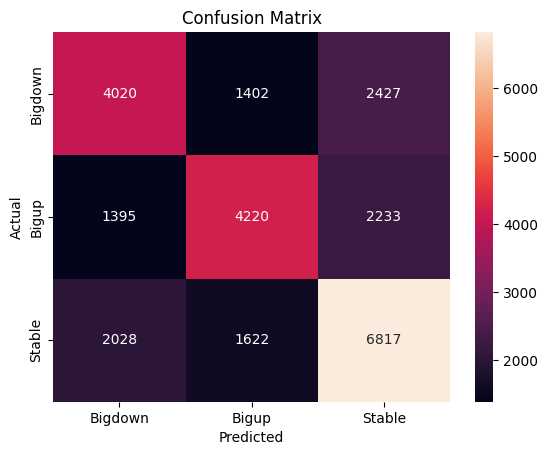

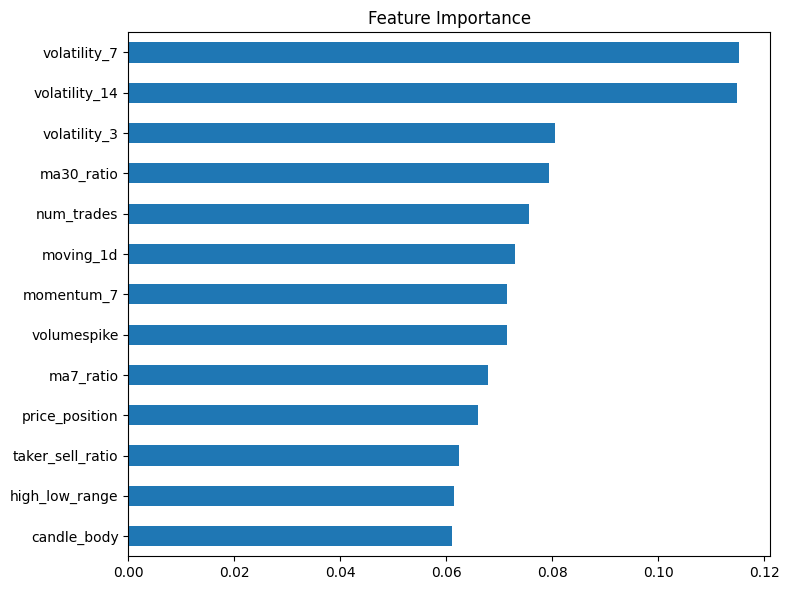

In [21]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder





drop_cols = [
    'label', 'date', 'type',
    'down_days_7',
    'taker_buy_volume',
    'z_score','taker_buy_ratio', 'negative_momentum',
]

X_train = train_df.drop(columns=drop_cols)
y_train = train_df['label']

X_test = test_df.drop(columns=drop_cols)
y_test = test_df['label']

le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

print("Label mapping:")
for i, class_name in enumerate(le.classes_):
    print(i, "=", class_name)


model = RandomForestClassifier(
    n_estimators=700,
    max_depth=13,
    min_samples_split=5,
    min_samples_leaf=3,
    max_features='sqrt',
    criterion='entropy',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

model.fit(X_train, y_train_encoded)






test_preds = model.predict(X_test)
print("\n--- Test Results ---")
print(classification_report(
    y_test_encoded,
    test_preds,
    target_names=le.classes_
))



cm = confusion_matrix(y_test_encoded, test_preds)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()


feat_imp = pd.Series(model.feature_importances_, index=X_train.columns)
feat_imp.sort_values().plot(kind='barh', figsize=(8, 6))
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

In [22]:
train_preds = model.predict(X_train)

print("--- Train Results ---")
print(classification_report(
    y_train_encoded,
    train_preds,
    target_names=le.classes_
))

print("--- Test Results ---")
print(classification_report(
    y_test_encoded,
    test_preds,
    target_names=le.classes_
))

--- Train Results ---
              precision    recall  f1-score   support

     Bigdown       0.76      0.70      0.73     15770
       Bigup       0.74      0.70      0.72     15771
      Stable       0.67      0.73      0.70     21039

    accuracy                           0.71     52580
   macro avg       0.72      0.71      0.71     52580
weighted avg       0.72      0.71      0.71     52580

--- Test Results ---
              precision    recall  f1-score   support

     Bigdown       0.54      0.51      0.53      7849
       Bigup       0.58      0.54      0.56      7848
      Stable       0.59      0.65      0.62     10467

    accuracy                           0.58     26164
   macro avg       0.57      0.57      0.57     26164
weighted avg       0.57      0.58      0.57     26164



In [12]:
print(y_train.unique())
print(sorted(y_train.unique()))

['Bigup' 'Stable' 'Bigdown']
['Bigdown', 'Bigup', 'Stable']


In [23]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
import pandas as pd
import numpy as np

drop_cols = [
    'label', 'date', 'type',
    'down_days_7',
    'taker_buy_volume',
    'z_score','taker_buy_ratio','taker_sell_ratio', 'negative_momentum',
]

X = df.drop(columns=drop_cols)
le = LabelEncoder()
y = le.fit_transform(df['label'])


groups = df['type']

logo = LeaveOneGroupOut()

results = []

for fold, (train_idx, test_idx) in enumerate(logo.split(X, y, groups), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    test_coin = groups.iloc[test_idx].unique()[0]

    model = RandomForestClassifier(
        n_estimators=700,
        max_depth=13,
        min_samples_split=5,
        min_samples_leaf=3,
        criterion='entropy',
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    macro_f1 = f1_score(y_test, preds, average='macro')
    weighted_f1 = f1_score(y_test, preds, average='weighted')

    results.append({
        'test_coin': test_coin,
        'accuracy': acc,
        'macro_f1': macro_f1,
        'weighted_f1': weighted_f1
    })

    print(f"\n===== Fold {fold} | Test coin: {test_coin} =====")
    print(classification_report(y_test, preds,target_names=le.classes_))


===== Fold 1 | Test coin: ADA =====
              precision    recall  f1-score   support

     Bigdown       0.73      0.69      0.71      3681
       Bigup       0.71      0.74      0.72      3682
      Stable       0.68      0.69      0.69      4924

    accuracy                           0.70     12287
   macro avg       0.71      0.70      0.70     12287
weighted avg       0.70      0.70      0.70     12287


===== Fold 2 | Test coin: AVAX =====
              precision    recall  f1-score   support

     Bigdown       0.73      0.69      0.71      3681
       Bigup       0.70      0.74      0.72      3682
      Stable       0.68      0.69      0.68      4924

    accuracy                           0.70     12287
   macro avg       0.70      0.70      0.70     12287
weighted avg       0.70      0.70      0.70     12287


===== Fold 3 | Test coin: BNB =====
              precision    recall  f1-score   support

     Bigdown       0.42      0.22      0.29      4164
       Bigup     

In [14]:
results_df = pd.DataFrame(results)

print(results_df)

print("\nAverage Results:")
print(results_df[['accuracy', 'macro_f1', 'weighted_f1']].mean())

  test_coin  accuracy  macro_f1  weighted_f1
0       ADA  0.702613  0.704543     0.702573
1      AVAX  0.701473  0.703534     0.701467
2       BNB  0.467824  0.408947     0.428492
3      DOGE  0.413850  0.399782     0.411177
4       ETH  0.427542  0.416688     0.425533
5       SOL  0.395327  0.395001     0.395298

Average Results:
accuracy       0.518105
macro_f1       0.504749
weighted_f1    0.510757
dtype: float64


# SVM


In [15]:

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

scaler = StandardScaler()
le = LabelEncoder()

drop_cols = [
    'label', 'date', 'type',
    'down_days_7',
    'taker_buy_volume',
    'z_score',
    'taker_buy_ratio',
    'taker_sell_ratio',
    'negative_momentum',
]

X_train = train_df.drop(columns=drop_cols)
y_train = train_df['label']

X_test = test_df.drop(columns=drop_cols)
y_test = test_df['label']

y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

print("Label mapping:")
for i, class_name in enumerate(le.classes_):
    print(i, "=", class_name)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = SVC(
    kernel='rbf',
    C=50,
    gamma='scale',
    class_weight='balanced',
    random_state=42
)

clf.fit(X_train_scaled, y_train_encoded)

predictions = clf.predict(X_test_scaled)


Label mapping:
0 = Bigdown
1 = Bigup
2 = Stable


Test Accuracy: 0.4919

--- SVM Test Results ---
              precision    recall  f1-score   support

     Bigdown       0.46      0.31      0.37      7849
       Bigup       0.47      0.36      0.41      7848
      Stable       0.51      0.72      0.60     10467

    accuracy                           0.49     26164
   macro avg       0.48      0.47      0.46     26164
weighted avg       0.48      0.49      0.47     26164



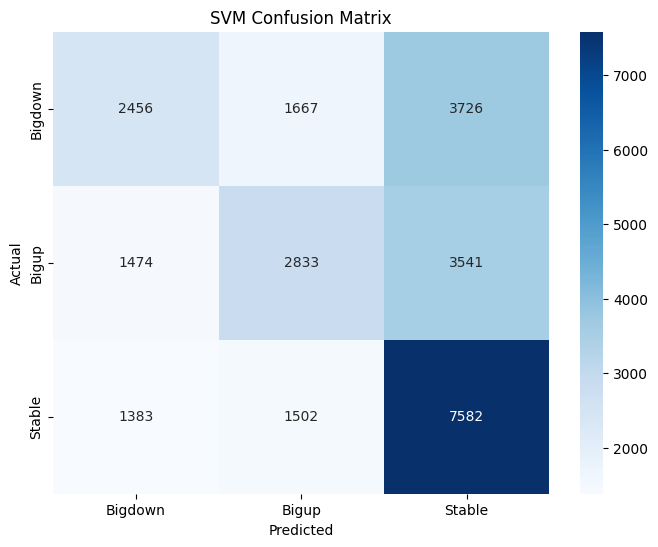


--- SVM Train Results ---
              precision    recall  f1-score   support

     Bigdown       0.52      0.42      0.46     15770
       Bigup       0.53      0.45      0.49     15771
      Stable       0.55      0.69      0.61     21039

    accuracy                           0.54     52580
   macro avg       0.53      0.52      0.52     52580
weighted avg       0.53      0.54      0.53     52580



In [17]:


svm_test_predictions = clf.predict(X_test_scaled)
svm_train_predictions = clf.predict(X_train_scaled)

print(f"Test Accuracy: {accuracy_score(y_test_encoded, svm_test_predictions):.4f}")

print("\n--- SVM Test Results ---")
print(classification_report(
    y_test_encoded,
    svm_test_predictions,
    target_names=le.classes_
))

cm_svm = confusion_matrix(y_test_encoded, svm_test_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("SVM Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

print("\n--- SVM Train Results ---")
print(classification_report(
    y_train_encoded,
    svm_train_predictions,
    target_names=le.classes_
))

In [ ]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report
import pandas as pd
import numpy as np

drop_cols = [
    'label', 'date', 'type',
    'down_days_7',
    'taker_buy_volume',
    'z_score',
    'taker_buy_ratio',
    'taker_sell_ratio',
    'negative_momentum',
]

X = df.drop(columns=drop_cols)
y = df['label']

groups = df['type']

logo = LeaveOneGroupOut()

results = []

for fold, (train_idx, test_idx) in enumerate(logo.split(X, y, groups), 1):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    test_coin = groups.iloc[test_idx].unique()[0]

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    clf = SVC(
    kernel='rbf',
    C=50,
    gamma='scale',
    class_weight='balanced',
    random_state=42
    )

    clf.fit(X_train_scaled, y_train)

    preds = clf.predict(X_test_scaled)

    acc = accuracy_score(y_test, preds)
    macro_f1 = f1_score(y_test, preds, average='macro')
    weighted_f1 = f1_score(y_test, preds, average='weighted')

    results.append({
        'test_coin': test_coin,
        'accuracy': acc,
        'macro_f1': macro_f1,
        'weighted_f1': weighted_f1
    })

    print(f"\n===== Fold {fold} | Test coin: {test_coin} =====")
    print(classification_report(y_test, preds))





===== Fold 1 | Test coin: ADA =====
              precision    recall  f1-score   support

     Bigdown       0.45      0.42      0.43      3681
       Bigup       0.46      0.47      0.47      3682
      Stable       0.56      0.59      0.57      4924

    accuracy                           0.50     12287
   macro avg       0.49      0.49      0.49     12287
weighted avg       0.50      0.50      0.50     12287



In [ ]:
results_df = pd.DataFrame(results)

print(results_df)

print("\nAverage Results:")
print(results_df[['accuracy', 'macro_f1', 'weighted_f1']].mean())

  test_coin  accuracy  macro_f1  weighted_f1
0       ADA  0.500366  0.490705     0.498984
1      AVAX  0.500366  0.490705     0.498984
2       BNB  0.457015  0.378874     0.401044
3      DOGE  0.452475  0.390034     0.410395
4       ETH  0.328313  0.299822     0.289950
5       SOL  0.404259  0.404170     0.407795

Average Results:
accuracy       0.440466
macro_f1       0.409052
weighted_f1    0.417859
dtype: float64


# logistic regression

Label mapping:
0 = Bigdown
1 = Bigup
2 = Stable
Training Logistic Regression... Train: 52580


C:\Users\ibrah\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



--- Train Results ---
              precision    recall  f1-score   support

     Bigdown       0.37      0.27      0.31     15770
       Bigup       0.40      0.33      0.36     15771
      Stable       0.50      0.66      0.57     21039

    accuracy                           0.44     52580
   macro avg       0.42      0.42      0.41     52580
weighted avg       0.43      0.44      0.43     52580


--- Test Results ---
              precision    recall  f1-score   support

     Bigdown       0.37      0.26      0.31      7849
       Bigup       0.39      0.36      0.37      7848
      Stable       0.51      0.65      0.57     10467

    accuracy                           0.45     26164
   macro avg       0.42      0.42      0.42     26164
weighted avg       0.43      0.45      0.43     26164

Test Accuracy: 0.44503898486469956


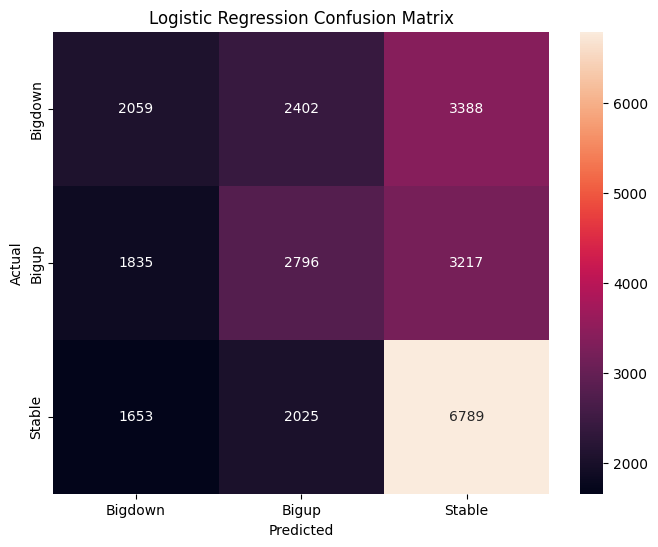

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

drop_cols = [
    'label', 'date', 'type',
    'down_days_7',
    'taker_buy_volume',
    'z_score',
    'taker_buy_ratio',
    'negative_momentum',
]


X_train = train_df.drop(columns=drop_cols)
y_train = train_df['label']

X_test = test_df.drop(columns=drop_cols)
y_test = test_df['label']

# Encode labels
le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

print("Label mapping:")
for i, class_name in enumerate(le.classes_):
    print(i, "=", class_name)

# Scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression model
log_reg = LogisticRegression(
    multi_class='multinomial',
    solver='saga',
    class_weight='balanced',
    max_iter=5000,
    random_state=42,
    n_jobs=-1
)

print(f"Training Logistic Regression... Train: {len(X_train_scaled)}")

log_reg.fit(X_train_scaled, y_train_encoded)

# Predictions
train_preds = log_reg.predict(X_train_scaled)
test_preds = log_reg.predict(X_test_scaled)

# Results
print("\n--- Train Results ---")
print(classification_report(
    y_train_encoded,
    train_preds,
    target_names=le.classes_
))

print("\n--- Test Results ---")
print(classification_report(
    y_test_encoded,
    test_preds,
    target_names=le.classes_
))

print("Test Accuracy:", accuracy_score(y_test_encoded, test_preds))

# Confusion Matrix
cm = confusion_matrix(y_test_encoded, test_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("Logistic Regression Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

In [11]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report
import pandas as pd
import numpy as np

drop_cols = [
    'label', 'date', 'type',
    'down_days_7',
    'taker_buy_volume',
    'z_score',
    'taker_buy_ratio',
    'taker_sell_ratio',
    'negative_momentum',
]

X = df.drop(columns=drop_cols)
le = LabelEncoder()
y = le.fit_transform(df['label'])
groups = df['type']

logo = LeaveOneGroupOut()
results = []

for fold, (train_idx, test_idx) in enumerate(logo.split(X, y, groups), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    test_coin = groups.iloc[test_idx].unique()[0]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    log_reg = LogisticRegression(
        multi_class='multinomial',
        solver='saga',
        class_weight='balanced',
        max_iter=5000,
        random_state=42,
        n_jobs=-1
    )

    log_reg.fit(X_train_scaled, y_train)

    preds = log_reg.predict(X_test_scaled)

    acc = accuracy_score(y_test, preds)
    macro_f1 = f1_score(y_test, preds, average='macro')
    weighted_f1 = f1_score(y_test, preds, average='weighted')

    results.append({
        'test_coin': test_coin,
        'accuracy': acc,
        'macro_f1': macro_f1,
        'weighted_f1': weighted_f1
    })

    print(f"\n===== Fold {fold} | Test coin: {test_coin} =====")
    print(classification_report(y_test, preds))

C:\Users\ibrah\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\ibrah\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\ibrah\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default valu


===== Fold 1 | Test coin: ADA =====
              precision    recall  f1-score   support

           0       0.36      0.30      0.33      3681
           1       0.37      0.38      0.37      3682
           2       0.53      0.57      0.55      4924

    accuracy                           0.44     12287
   macro avg       0.42      0.42      0.42     12287
weighted avg       0.43      0.44      0.43     12287



C:\Users\ibrah\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\ibrah\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



===== Fold 2 | Test coin: AVAX =====
              precision    recall  f1-score   support

           0       0.36      0.30      0.33      3681
           1       0.37      0.38      0.37      3682
           2       0.53      0.57      0.55      4924

    accuracy                           0.44     12287
   macro avg       0.42      0.42      0.42     12287
weighted avg       0.43      0.44      0.43     12287



C:\Users\ibrah\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\ibrah\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



===== Fold 3 | Test coin: BNB =====
              precision    recall  f1-score   support

           0       0.41      0.15      0.22      4164
           1       0.45      0.19      0.27      4165
           2       0.46      0.87      0.60      5548

    accuracy                           0.45     13877
   macro avg       0.44      0.41      0.36     13877
weighted avg       0.44      0.45      0.39     13877


===== Fold 4 | Test coin: DOGE =====
              precision    recall  f1-score   support

           0       0.39      0.23      0.29      4168
           1       0.41      0.31      0.35      4166
           2       0.49      0.73      0.59      5543

    accuracy                           0.45     13877
   macro avg       0.43      0.42      0.41     13877
weighted avg       0.44      0.45      0.43     13877



C:\Users\ibrah\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\ibrah\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\ibrah\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default valu


===== Fold 5 | Test coin: ETH =====
              precision    recall  f1-score   support

           0       0.31      0.65      0.42      4166
           1       0.41      0.28      0.33      4165
           2       0.53      0.20      0.30      5546

    accuracy                           0.36     13877
   macro avg       0.42      0.38      0.35     13877
weighted avg       0.43      0.36      0.34     13877


===== Fold 6 | Test coin: SOL =====
              precision    recall  f1-score   support

           0       0.37      0.33      0.35      3759
           1       0.37      0.44      0.40      3759
           2       0.54      0.50      0.52      5021

    accuracy                           0.43     12539
   macro avg       0.43      0.43      0.42     12539
weighted avg       0.44      0.43      0.43     12539



C:\Users\ibrah\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [12]:
results_df = pd.DataFrame(results)

print(results_df)

print("\nAverage Results:")
print(results_df[['accuracy', 'macro_f1', 'weighted_f1']].mean())

  test_coin  accuracy  macro_f1  weighted_f1
0       ADA  0.435338  0.417772     0.431150
1      AVAX  0.435338  0.417772     0.431150
2       BNB  0.451683  0.363343     0.386955
3      DOGE  0.453412  0.408696     0.426294
4       ETH  0.363695  0.350033     0.344588
5       SOL  0.433767  0.424827     0.434346

Average Results:
accuracy       0.428872
macro_f1       0.397074
weighted_f1    0.409081
dtype: float64


# KNN

In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.inspection import permutation_importance
from sklearn.model_selection import LeaveOneGroupOut
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [14]:
drop_cols = ['label', 'date', 'type', 'down_days_7', 'taker_buy_volume',
             'z_score', 'taker_buy_ratio', 'taker_sell_ratio', 'negative_momentum']

X_train = train_df.drop(columns=drop_cols)
X_test  = test_df.drop(columns=drop_cols)

y_train = train_df['label']
y_test  = test_df['label']
le = LabelEncoder()
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

 KNN Test Results 
              precision    recall  f1-score   support

     Bigdown       0.43      0.43      0.43      7849
       Bigup       0.45      0.35      0.40      7848
      Stable       0.54      0.62      0.58     10467

    accuracy                           0.48     26164
   macro avg       0.47      0.47      0.47     26164
weighted avg       0.48      0.48      0.48     26164



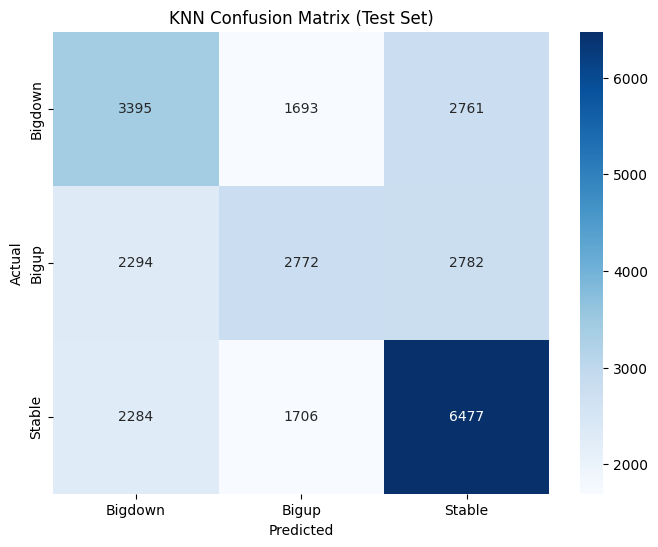

--- KNN Train Results ---
              precision    recall  f1-score   support

     Bigdown       0.49      0.52      0.50     15770
       Bigup       0.54      0.43      0.48     15771
      Stable       0.59      0.65      0.62     21039

    accuracy                           0.55     52580
   macro avg       0.54      0.53      0.53     52580
weighted avg       0.55      0.55      0.54     52580



In [15]:
knn = KNeighborsClassifier(
    n_neighbors=9,
    weights='uniform',
    metric='euclidean',
    n_jobs=-1
)

knn.fit(X_train_scaled, y_train_encoded)

knn_test_predictions = knn.predict(X_test_scaled)

print(" KNN Test Results ")
print(classification_report(
    y_test_encoded,
    knn_test_predictions,
    target_names=le.classes_
))

plt.figure(figsize=(8, 6))
sns.heatmap(
    confusion_matrix(y_test_encoded, knn_test_predictions),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title('KNN Confusion Matrix (Test Set)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

knn_train_predictions = knn.predict(X_train_scaled)

print("--- KNN Train Results ---")
print(classification_report(
    y_train_encoded,
    knn_train_predictions,
    target_names=le.classes_
))

 KNN Test Results 
              precision    recall  f1-score   support

     Bigdown       0.70      0.61      0.65      7849
       Bigup       0.69      0.62      0.66      7848
      Stable       0.68      0.80      0.74     10467

    accuracy                           0.69     26164
   macro avg       0.69      0.68      0.68     26164
weighted avg       0.69      0.69      0.69     26164



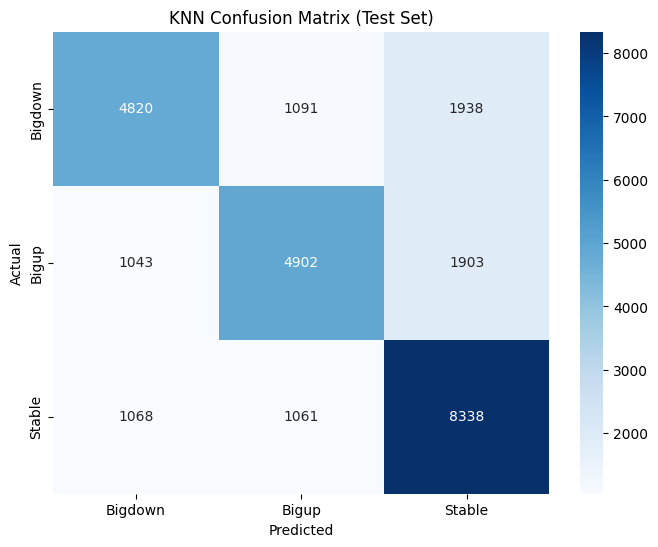

--- KNN Train Results ---
              precision    recall  f1-score   support

     Bigdown       1.00      1.00      1.00     15770
       Bigup       1.00      1.00      1.00     15771
      Stable       1.00      1.00      1.00     21039

    accuracy                           1.00     52580
   macro avg       1.00      1.00      1.00     52580
weighted avg       1.00      1.00      1.00     52580



In [16]:
knn = KNeighborsClassifier(
    n_neighbors=6,
    weights='distance',
    metric='euclidean',
    n_jobs=-1
)

knn.fit(X_train_scaled, y_train_encoded)

knn_test_predictions = knn.predict(X_test_scaled)

print(" KNN Test Results ")
print(classification_report(
    y_test_encoded,
    knn_test_predictions,
    target_names=le.classes_
))

plt.figure(figsize=(8, 6))
sns.heatmap(
    confusion_matrix(y_test_encoded, knn_test_predictions),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title('KNN Confusion Matrix (Test Set)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

knn_train_predictions = knn.predict(X_train_scaled)

print("--- KNN Train Results ---")
print(classification_report(
    y_train_encoded,
    knn_train_predictions,
    target_names=le.classes_
))

In [ ]:
for k in [5, 7, 9, 11, 15, 21, 31,70]:
    knn = KNeighborsClassifier(
        n_neighbors=k,
        weights='uniform',
        metric='euclidean',
        n_jobs=-1
    )
    knn.fit(X_train_scaled, y_train)
    train_acc = knn.score(X_train_scaled, y_train)
    test_acc = knn.score(X_test_scaled, y_test)
    print(k, "Train:", train_acc, "Test:", test_acc)

5 Train: 0.5953974895397489 Test: 0.4943815930285889
7 Train: 0.5654050969950551 Test: 0.4858966518880905
9 Train: 0.5467097755800685 Test: 0.4832594404525302
11 Train: 0.5357360213008748 Test: 0.47829078122611224
15 Train: 0.5195321414986687 Test: 0.4751567038679101
21 Train: 0.5031761125903386 Test: 0.469538296896499
31 Train: 0.49089007227082543 Test: 0.46934719461855984
70 Train: 0.47095853936858123 Test: 0.4621617489680477


In [17]:
logo = LeaveOneGroupOut()
knn_cv_results = []

drop_cols = [
    'label', 'date', 'type',
    'down_days_7',
    'taker_buy_volume',
    'z_score',
    'taker_buy_ratio',
    'taker_sell_ratio',
    'negative_momentum',
]

X = df.drop(columns=drop_cols)
le = LabelEncoder()
y = le.fit_transform(df['label'])

groups = df['type']

for fold, (train_idx, test_idx) in enumerate(logo.split(X, y, groups), 1):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]
    coin = groups.iloc[test_idx].unique()[0]

    scaler_cv = StandardScaler()
    X_tr_scaled = scaler_cv.fit_transform(X_tr)
    X_te_scaled = scaler_cv.transform(X_te)

    model = KNeighborsClassifier(n_neighbors=10, weights='distance', n_jobs=-1)
    model.fit(X_tr_scaled, y_tr)
    pred = model.predict(X_te_scaled)

    knn_cv_results.append({
        'test_coin': coin,
        'accuracy': accuracy_score(y_te, pred),
        'macro_f1': f1_score(y_te, pred, average='macro'),
        'weighted_f1': f1_score(y_te, pred, average='weighted')
    })

    print(f"\nFold {fold} | Test Coin: {coin} ")
    print(classification_report(y_te, pred, target_names=le.classes_))





Fold 1 | Test Coin: ADA 
              precision    recall  f1-score   support

     Bigdown       1.00      1.00      1.00      3681
       Bigup       1.00      1.00      1.00      3682
      Stable       1.00      1.00      1.00      4924

    accuracy                           1.00     12287
   macro avg       1.00      1.00      1.00     12287
weighted avg       1.00      1.00      1.00     12287


Fold 2 | Test Coin: AVAX 
              precision    recall  f1-score   support

     Bigdown       1.00      1.00      1.00      3681
       Bigup       1.00      1.00      1.00      3682
      Stable       1.00      1.00      1.00      4924

    accuracy                           1.00     12287
   macro avg       1.00      1.00      1.00     12287
weighted avg       1.00      1.00      1.00     12287


Fold 3 | Test Coin: BNB 
              precision    recall  f1-score   support

     Bigdown       0.34      0.25      0.29      4164
       Bigup       0.35      0.25      0.29      4

In [18]:
cv_df = pd.DataFrame(knn_cv_results)
print("\n" + "="*60)
print(cv_df.round(4))
print("\nKNN Average Performance:")
print(cv_df.mean(numeric_only=True).round(4))


  test_coin  accuracy  macro_f1  weighted_f1
0       ADA    1.0000    1.0000       1.0000
1      AVAX    1.0000    1.0000       1.0000
2       BNB    0.4030    0.3692       0.3847
3      DOGE    0.4217    0.3906       0.4058
4       ETH    0.3465    0.3108       0.3085
5       SOL    0.4050    0.3992       0.4066

KNN Average Performance:
accuracy       0.5960
macro_f1       0.5783
weighted_f1    0.5843
dtype: float64


In [19]:
logo = LeaveOneGroupOut()
knn_cv_results = []

drop_cols = [
    'label', 'date', 'type',
    'down_days_7',
    'taker_buy_volume',
    'z_score',
    'taker_buy_ratio',
    'taker_sell_ratio',
    'negative_momentum',
]

X = df.drop(columns=drop_cols)
le = LabelEncoder()
y = le.fit_transform(df['label'])
groups = df['type']

for fold, (train_idx, test_idx) in enumerate(logo.split(X, y, groups), 1):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]
    coin = groups.iloc[test_idx].unique()[0]

    scaler_cv = StandardScaler()
    X_tr_scaled = scaler_cv.fit_transform(X_tr)
    X_te_scaled = scaler_cv.transform(X_te)

    model = KNeighborsClassifier(n_neighbors=9, weights='uniform', n_jobs=-1)
    model.fit(X_tr_scaled, y_tr)
    pred = model.predict(X_te_scaled)

    knn_cv_results.append({
        'test_coin': coin,
        'accuracy': accuracy_score(y_te, pred),
        'macro_f1': f1_score(y_te, pred, average='macro'),
        'weighted_f1': f1_score(y_te, pred, average='weighted')
    })

    print(f"\nFold {fold} | Test Coin: {coin} ")
    print(classification_report(y_te, pred, target_names=le.classes_))





Fold 1 | Test Coin: ADA 
              precision    recall  f1-score   support

     Bigdown       0.49      0.54      0.51      3681
       Bigup       0.53      0.46      0.49      3682
      Stable       0.62      0.63      0.63      4924

    accuracy                           0.55     12287
   macro avg       0.54      0.54      0.54     12287
weighted avg       0.55      0.55      0.55     12287


Fold 2 | Test Coin: AVAX 
              precision    recall  f1-score   support

     Bigdown       0.49      0.54      0.51      3681
       Bigup       0.53      0.46      0.49      3682
      Stable       0.62      0.63      0.63      4924

    accuracy                           0.55     12287
   macro avg       0.54      0.54      0.54     12287
weighted avg       0.55      0.55      0.55     12287


Fold 3 | Test Coin: BNB 
              precision    recall  f1-score   support

     Bigdown       0.33      0.32      0.32      4164
       Bigup       0.34      0.24      0.28      4

In [20]:
cv_df = pd.DataFrame(knn_cv_results)
print("\n" + "="*60)
print(cv_df.round(4))
print("\nKNN Average Performance:")
print(cv_df.mean(numeric_only=True).round(4))


  test_coin  accuracy  macro_f1  weighted_f1
0       ADA    0.5516    0.5422       0.5507
1      AVAX    0.5516    0.5422       0.5507
2       BNB    0.3959    0.3706       0.3844
3      DOGE    0.4203    0.3969       0.4105
4       ETH    0.3366    0.2914       0.2869
5       SOL    0.3971    0.3941       0.4000

KNN Average Performance:
accuracy       0.4422
macro_f1       0.4229
weighted_f1    0.4305
dtype: float64


# XGBOOST

Train Accuracy: 0.7087485736021301
Test Accuracy: 0.5365005350863782

--- XGBoost Test Results ---
              precision    recall  f1-score   support

     Bigdown       0.45      0.55      0.50      7849
       Bigup       0.54      0.49      0.51      7848
      Stable       0.62      0.56      0.59     10467

    accuracy                           0.54     26164
   macro avg       0.54      0.53      0.53     26164
weighted avg       0.55      0.54      0.54     26164



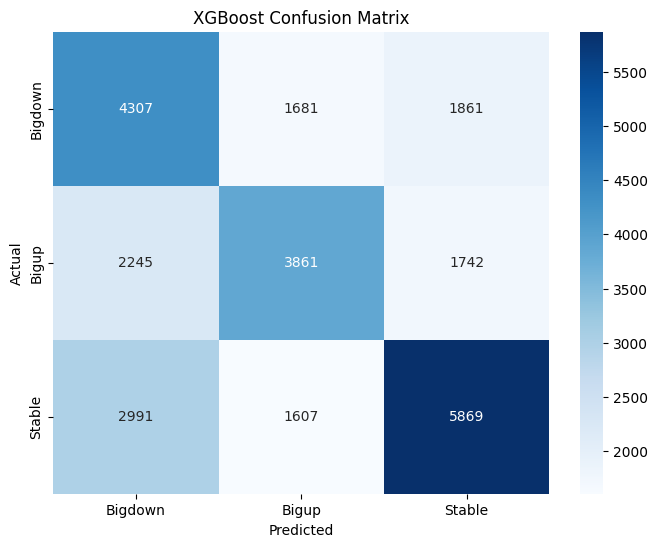

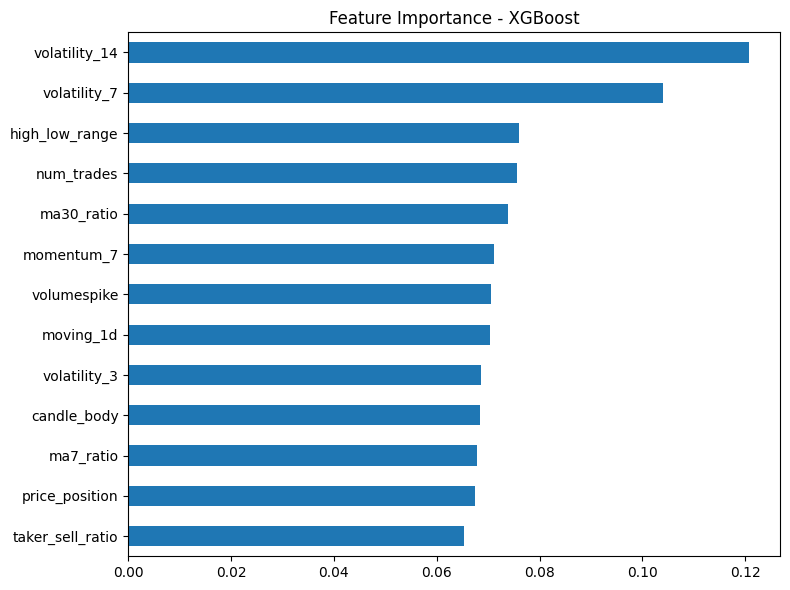

In [ ]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

drop_cols = [
    'label', 'date', 'type',
    'down_days_7',
    'taker_buy_volume',
    'z_score',
    'taker_buy_ratio',
    'negative_momentum',
]

X_train = train_df.drop(columns=drop_cols)
y_train = train_df['label']

X_test = test_df.drop(columns=drop_cols)
y_test = test_df['label']

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

model = XGBClassifier(
    n_estimators=700,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',
    num_class=3,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train_enc)

train_preds = model.predict(X_train)
test_preds = model.predict(X_test)

print("Train Accuracy:", accuracy_score(y_train_enc, train_preds))
print("Test Accuracy:", accuracy_score(y_test_enc, test_preds))

print("\n--- XGBoost Test Results ---")
print(classification_report(
    y_test_enc,
    test_preds,
    target_names=le.classes_
))

cm = confusion_matrix(y_test_enc, test_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title("XGBoost Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

feat_imp = pd.Series(model.feature_importances_, index=X_train.columns)
feat_imp.sort_values().plot(kind='barh', figsize=(8, 6))
plt.title("Feature Importance - XGBoost")
plt.tight_layout()
plt.show()

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report
import pandas as pd

logo = LeaveOneGroupOut()
xgb_cv_results = []

drop_cols = [
    'label', 'date', 'type',
    'down_days_7',
    'taker_buy_volume',
    'z_score',
    'taker_buy_ratio',
    'taker_sell_ratio',
    'negative_momentum',
]

X = df.drop(columns=drop_cols).astype('float32')
y = df['label']
groups = df['type']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

for fold, (train_idx, test_idx) in enumerate(logo.split(X, y_encoded, groups), 1):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y_encoded[train_idx], y_encoded[test_idx]

    coin = groups.iloc[test_idx].unique()[0]

    model = XGBClassifier(
    n_estimators=700,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',
    num_class=3,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)


    model.fit(X_tr, y_tr)

    pred = model.predict(X_te)

    xgb_cv_results.append({
        'test_coin': coin,
        'accuracy': accuracy_score(y_te, pred),
        'macro_f1': f1_score(y_te, pred, average='macro'),
        'weighted_f1': f1_score(y_te, pred, average='weighted')
    })

    print(f"\nFold {fold} | Test Coin: {coin}")
    print(classification_report(
        y_te,
        pred,
        target_names=le.classes_
    ))



Fold 1 | Test Coin: ADA
              precision    recall  f1-score   support

     Bigdown       0.74      0.52      0.61      3681
       Bigup       0.72      0.56      0.63      3682
      Stable       0.61      0.85      0.71      4924

    accuracy                           0.66     12287
   macro avg       0.69      0.64      0.65     12287
weighted avg       0.68      0.66      0.66     12287


Fold 2 | Test Coin: AVAX
              precision    recall  f1-score   support

     Bigdown       0.73      0.51      0.60      3681
       Bigup       0.73      0.56      0.64      3682
      Stable       0.61      0.85      0.71      4924

    accuracy                           0.66     12287
   macro avg       0.69      0.64      0.65     12287
weighted avg       0.68      0.66      0.66     12287


Fold 3 | Test Coin: BNB
              precision    recall  f1-score   support

     Bigdown       0.42      0.17      0.24      4164
       Bigup       0.43      0.27      0.33      4165

In [ ]:
cv_df = pd.DataFrame(xgb_cv_results)
print("\n" + "="*60)
print(cv_df.round(4))
print("\nXGBoost Average Performance:")
print(cv_df.mean(numeric_only=True).round(4))


  test_coin  accuracy  macro_f1  weighted_f1
0       ADA    0.6623    0.6491       0.6551
1      AVAX    0.6644    0.6509       0.6571
2       BNB    0.4564    0.3897       0.4102
3      DOGE    0.3442    0.3419       0.3386
4       ETH    0.4296    0.4097       0.4218
5       SOL    0.4093    0.4081       0.4130

XGBoost Average Performance:
accuracy       0.4944
macro_f1       0.4749
weighted_f1    0.4826
dtype: float64


In [8]:
df1=df.copy()

In [9]:
df1.head()

,date,num_trades,taker_buy_volume,type,candle_body,high_low_range,ma7_ratio,ma30_ratio,moving_1d,volatility_7,...,z_score,taker_buy_ratio,price_position,momentum_7,taker_sell_ratio,negative_momentum,down_days_7,volatility_14,volatility_3,label
13877,2020-01-05 20:00:00,22032,22539.74791,ETH,135.351467,137.068569,-0.004685,0.023770,-1.884468,1.223157,...,1.054167,0.479223,0.301299,0.012339,0.520777,0.0,3.0,0.912849,1.792502,Bigup
13878,2020-01-06 00:00:00,29327,38530.67457,ETH,139.471601,138.703192,0.019941,0.052463,3.043510,1.638357,...,2.149177,0.473087,0.962578,0.039419,0.526913,0.0,3.0,1.191829,2.464251,Stable
13879,2020-01-06 04:00:00,14818,15428.41043,ETH,138.851502,139.002376,0.012541,0.045516,-0.444476,1.623014,...,1.776362,0.483735,0.226027,0.019903,0.516265,0.0,4.0,1.204572,2.533923,Bigup
13880,2020-01-06 08:00:00,32092,38378.76286,ETH,141.521504,142.079288,0.026109,0.062738,1.922661,1.718406,...,2.239662,0.440804,0.642353,0.040582,0.559196,0.0,3.0,1.245978,1.780716,Bigdown
13881,2020-01-06 12:00:00,35498,51023.28882,ETH,140.181240,142.227989,0.011023,0.050541,-0.946729,1.751498,...,1.713340,0.500594,0.270531,0.037980,0.499406,0.0,3.0,1.299540,1.532373,Bigup


In [10]:
df1["type"].value_counts()

,count
type,
ETH,13877
BNB,13877
DOGE,13877
SOL,12539
ADA,12287
AVAX,12287


# forcasting ADA and AVAX


In [11]:

df1 = df1[df1["type"].isin(["ADA", "AVAX"])]

In [12]:
df1.head()

,date,num_trades,taker_buy_volume,type,candle_body,high_low_range,ma7_ratio,ma30_ratio,moving_1d,volatility_7,...,z_score,taker_buy_ratio,price_position,momentum_7,taker_sell_ratio,negative_momentum,down_days_7,volatility_14,volatility_3,label
68047,2020-09-27 00:00:00,6414,180752.52,ADA,3.5713,3.726678,0.001136,0.021970,1.134956,2.914086,...,0.215078,0.506958,0.299310,-0.030148,0.493042,-0.030148,4.0,4.335621,2.797051,Bigdown
68048,2020-09-27 04:00:00,4829,90493.82,ADA,3.3784,3.605554,-0.036359,-0.017265,-4.219806,3.005490,...,-0.171065,0.404010,0.243475,-0.034744,0.595990,-0.034744,4.0,3.368977,2.702848,Bigdown
68049,2020-09-27 08:00:00,3336,87393.83,ADA,3.2930,3.405616,-0.043516,-0.025681,-1.950484,2.562668,...,-0.301150,0.438666,0.295330,-0.082692,0.561334,-0.082692,5.0,3.351469,2.687726,Bigup
68050,2020-09-27 12:00:00,5332,221845.28,ADA,3.4230,3.494690,-0.010091,0.005701,3.028185,2.925109,...,0.067318,0.559559,0.999368,-0.031021,0.440441,-0.031021,4.0,3.455806,3.707433,Stable
68051,2020-09-27 16:00:00,3082,91013.61,ADA,3.3945,3.508624,-0.014089,-0.000131,-0.644359,2.838556,...,-0.001550,0.534119,0.264296,-0.016890,0.465881,-0.016890,4.0,3.250394,2.581366,Bigup


In [13]:
df1 = df1.sort_values(by=['date'])

In [14]:
split = int(len(df1) * 0.80)

train_df = df1.iloc[:split]
test_df  = df1.iloc[split:]

# Verify
print(f"Train: {len(train_df)}")
print(f"Test:  {len(test_df)}")
print(f"Train date range: {train_df['date'].min()} → {train_df['date'].max()}")
print(f"Test date range:  {test_df['date'].min()} → {test_df['date'].max()}")
print(f"Coins in train: {train_df['type'].unique()}")
print(f"Coins in test:  {test_df['type'].unique()}")

Train: 19659
Test:  4915
Train date range: 2020-09-27 00:00:00 → 2025-03-23 04:00:00
Test date range:  2025-03-23 04:00:00 → 2026-05-06 16:00:00
Coins in train: ['ADA' 'AVAX']
Coins in test:  ['AVAX' 'ADA']


Train: 19659 | Test: 4915

--- Test Results ---
              precision    recall  f1-score   support

     Bigdown       0.63      0.54      0.58      1447
       Bigup       0.62      0.57      0.59      1490
      Stable       0.60      0.70      0.65      1978

    accuracy                           0.61      4915
   macro avg       0.62      0.60      0.61      4915
weighted avg       0.62      0.61      0.61      4915



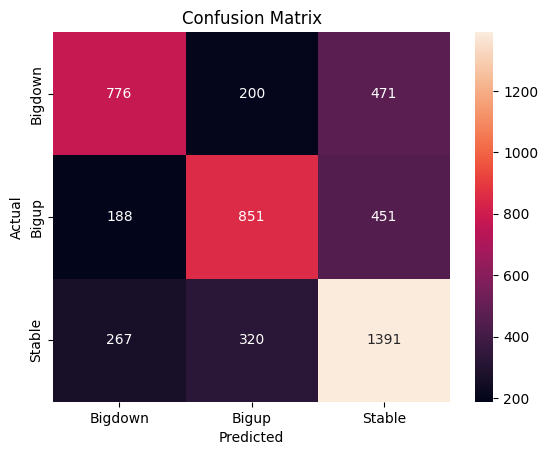

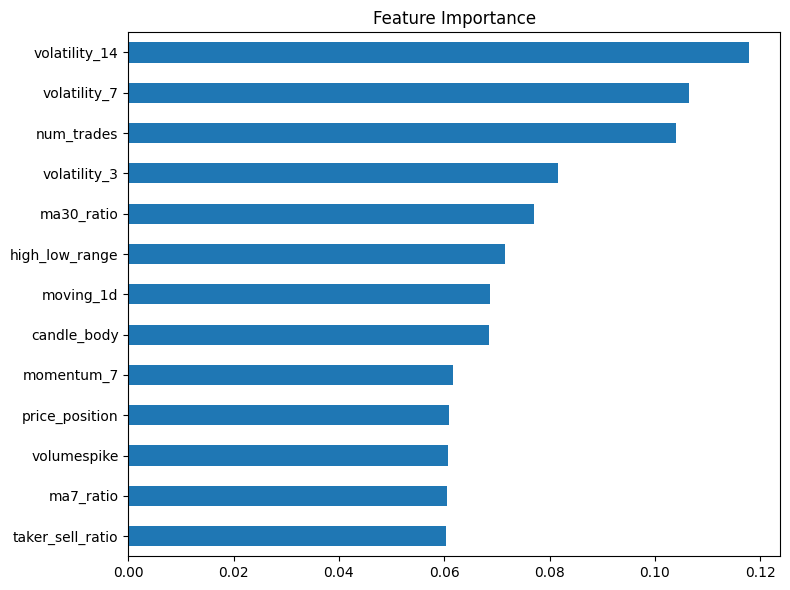

In [ ]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns


# =========================
# Drop columns
# =========================

drop_cols = [
    'label',
    'type',
    'date',
    'down_days_7',
    'taker_buy_volume',
    'z_score',
    'taker_buy_ratio',
    'negative_momentum',
]

X = df1.drop(columns=drop_cols)
y = df1['label']



X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=3,
    max_features='sqrt',
    criterion='entropy',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")

model.fit(X_train, y_train)


test_preds = model.predict(X_test)

print("\n--- Test Results ---")

print(classification_report(
    y_test,
    test_preds,
    target_names=['Bigdown', 'Bigup', 'Stable']
))


cm = confusion_matrix(y_test, test_preds)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Bigdown', 'Bigup', 'Stable'],
    yticklabels=['Bigdown', 'Bigup', 'Stable']
)

plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()


feat_imp = pd.Series(model.feature_importances_, index=X_train.columns)

feat_imp.sort_values().plot(kind='barh', figsize=(8, 6))

plt.title("Feature Importance")
plt.tight_layout()
plt.show()

In [ ]:
train_preds = model.predict(X_train)
print("--- Train Results ---")
print(classification_report(y_train, train_preds, target_names=['Bigdown', 'Bigup','Stable']))

print("--- Test Results ---")
print(classification_report(y_test, test_preds, target_names=['Bigdown', 'Bigup','Stable']))

--- Train Results ---
              precision    recall  f1-score   support

     Bigdown       0.82      0.74      0.78      5915
       Bigup       0.79      0.73      0.76      5874
      Stable       0.69      0.79      0.74      7870

    accuracy                           0.75     19659
   macro avg       0.77      0.75      0.76     19659
weighted avg       0.76      0.75      0.76     19659

--- Test Results ---
              precision    recall  f1-score   support

     Bigdown       0.63      0.54      0.58      1447
       Bigup       0.62      0.57      0.59      1490
      Stable       0.60      0.70      0.65      1978

    accuracy                           0.61      4915
   macro avg       0.62      0.60      0.61      4915
weighted avg       0.62      0.61      0.61      4915



In [15]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
drop_cols = [
    'label',
    'type',
    'date',
    'down_days_7',
    'taker_buy_volume',
    'z_score',
    'taker_buy_ratio',
    'negative_momentum',
]

feature_cols = [col for col in df1.columns if col not in drop_cols]

In [19]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df1['label_encoded'] = le.fit_transform(df1['label'])

print(le.classes_)

['Bigdown' 'Bigup' 'Stable']


In [22]:
split = int(len(df1) * 0.8)

train_df = df1.iloc[:split].copy()
test_df = df1.iloc[split:].copy()

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
test_df[feature_cols] = scaler.transform(test_df[feature_cols])

In [24]:
import numpy as np

time_steps = 24

def create_sequences(data, feature_cols, time_steps):
    X_seq = []
    y_seq = []

    X_values = data[feature_cols].values
    y_values = data['label_encoded'].values

    for i in range(time_steps, len(data)):
        X_seq.append(X_values[i-time_steps:i])
        y_seq.append(y_values[i])

    return np.array(X_seq), np.array(y_seq)

X_train, y_train = create_sequences(train_df, feature_cols, time_steps)
X_test, y_test = create_sequences(test_df, feature_cols, time_steps)

print(X_train.shape)
print(X_test.shape)

(19635, 24, 13)
(4891, 24, 13)


In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout,BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

num_classes = len(le.classes_)

y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.3),

    LSTM(64, return_sequences=True),
    Dropout(0.3),

    LSTM(32),
    Dropout(0.2),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation='relu'),

    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/50
307/307 ━━━━━━━━━━━━━━━━━━━━ 35s 84ms/step - accuracy: 0.4069 - loss: 1.1053 - val_accuracy: 0.4598 - val_loss: 1.0570
Epoch 2/50
307/307 ━━━━━━━━━━━━━━━━━━━━ 26s 85ms/step - accuracy: 0.4193 - loss: 1.0669 - val_accuracy: 0.4492 - val_loss: 1.0571
Epoch 3/50
307/307 ━━━━━━━━━━━━━━━━━━━━ 25s 83ms/step - accuracy: 0.4233 - loss: 1.0609 - val_accuracy: 0.4269 - val_loss: 1.0755
Epoch 4/50
307/307 ━━━━━━━━━━━━━━━━━━━━ 42s 86ms/step - accuracy: 0.4294 - loss: 1.0555 - val_accuracy: 0.4611 - val_loss: 1.0525
Epoch 5/50
307/307 ━━━━━━━━━━━━━━━━━━━━ 27s 87ms/step - accuracy: 0.4359 - loss: 1.0503 - val_accuracy: 0.4823 - val_loss: 1.0424
Epoch 6/50
307/307 ━━━━━━━━━━━━━━━━━━━━ 40s 85ms/step - accuracy: 0.4404 - loss: 1.0492 - val_accuracy: 0.4727 - val_loss: 1.0480
Epoch 7/50
307/307 ━━━━━━━━━━━━━━━━━━━━ 26s 84ms/step - accuracy: 0.4419 - loss: 1.0429 - val_accuracy: 0.4747 - val_loss: 1.0425
Epoch 8/50
307/307 ━━━━━━━━━━━━━━━━━━━━ 27s 87ms/step - accuracy: 0.4380 - loss: 1.0433 - 